# Pre-EFA Assumption Checks

Runs all pre-EFA diagnostics. Edit the **Paths** cell before running.

**Pre-EFA:** sample size, correlation matrix, normality, outliers, and KMO & Bartlett's  

In [1]:
from pathlib import Path
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from langdetect import detect, LangDetectException
from collections import defaultdict
from sklearn.preprocessing import PowerTransformer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import joblib

from ep_pipeline.config import MetricsConfig
from ep_pipeline.io import load_csv, write_table
from ep_pipeline.efa.efa import prepare_features, scale_metrics, parallel_analysis, plot_scree, fit_efa
from ep_pipeline.efa.metric_taxonomy import CATEGORY_OF

/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Removing noisy data

In [3]:
PROJECT_ROOT = Path('/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper')
TEXT_FP_DETECT = PROJECT_ROOT / 'data' / 'human_texts_2023_2025.csv'
CHR27_FP       = PROJECT_ROOT / 'data' / 'data_subset_chr27.csv'
IN_FP       = PROJECT_ROOT / 'data' / 'AO3metrics_full.csv'
VIS_DIR     = PROJECT_ROOT / 'outputs' / 'visualizations'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results' / 'efa_assumptions'
VIS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cfg = MetricsConfig()
random.seed(2001)

In [23]:
CLEANED_FP = PROJECT_ROOT / 'data' / 'all_metrics_cleaned.csv'

if CLEANED_FP.exists():
    all_metrics = pd.read_csv(CLEANED_FP)
    print(f"Loaded cached cleaned data → {CLEANED_FP}  ({len(all_metrics):,} rows)")
    print("The detection/filtering cells below will detect the cache and skip themselves.")
else:
    all_metrics = None
    print("No cache found — run the detection/filtering cells below; they'll save the cache at the end.")

No cache found — run the detection/filtering cells below; they'll save the cache at the end.


In [24]:
if all_metrics is None:
    # Mirror the combine step in run_AO3_scoring.py so detection covers the full dataset
    _texts_full  = pd.read_csv(TEXT_FP_DETECT, usecols=['work_id', 'text'])
    _texts_chr27 = pd.read_csv(CHR27_FP,       usecols=['work_id', 'text'])
    texts = (
        pd.concat([_texts_full, _texts_chr27], ignore_index=True)
        .rename(columns={'work_id': 'id'})
        .dropna(subset=['text'])
    )

    meta = pd.read_csv(IN_FP, usecols=['id', 'title', 'author', 'fandom', 'words'])

    def safe_detect(text, chars=10000):
        try:
            return detect(str(text)[:chars])
        except LangDetectException:
            return 'unknown'

    texts['lang'] = texts['text'].apply(safe_detect)

    flagged = (
        texts[texts['lang'] != 'en']
        .merge(meta, on='id', how='inner')
        .sort_values('words', ascending=False)
    )
    NON_ENGLISH_DETECTED = set(flagged['id'])

    print(f"Flagged {len(NON_ENGLISH_DETECTED)} non-English texts — inspect, then run next cell\n")
    for i, row in flagged.iterrows():
        print(f"{'─'*60}")
        print(f"id={row['id']}  lang={row['lang']}  words={int(row['words'])}")
        print(f"  title : {row['title']}")
        print(f"  author: {row['author']}")
        print(f"  fandom: {row['fandom']}")
        print(f"  text  : {str(row['text'])[:300]}")
        print()
else:
    print("Using cached cleaned data — skipping non-English detection.")

Flagged 630 non-English texts — inspect, then run next cell

────────────────────────────────────────────────────────────
id=58051213  lang=es  words=265748
  title : La Favorita del Tirano
  author: RedTsundere
  fandom: ['Zhou Shu Hui Zhan  | Jujutsu Kaisen (Manga)', 'Zhou Shu Hui Zhan  | Jujutsu Kaisen (Anime)']
  text  : Chapter 1: El Rey No Escucha Bien          Chapter Text Sukuna caminaba por los pasillos iluminados por el sol oscuro que gobernaba entre los reinos. Sus pasos largos y pesados hacian retumbar el piso de marmol. Su perfil afilado, sus hombros tatuados y su gran estatura, contrastado por el cielo roj

────────────────────────────────────────────────────────────
id=53129296  lang=so  words=247392
  title : i dream of car crash
  author: Kagamiraa
  fandom: ['Yuan Shen  | Genshin Impact (Video Game)']
  text  : Chapter 1: gold liquor, blonde hair          Chapter Text  khwaamsamphanthaennaefnrahwaangbukhkhlnanaimaidtaang`aaircchaakdaabs`ngkhm  haakyindiithiiccha`yuurw

In [25]:
if all_metrics is None:
    all_metrics = load_csv(IN_FP).drop_duplicates(subset='id').reset_index(drop=True)

    exclude = NON_ENGLISH_DETECTED
    all_metrics = all_metrics[~all_metrics['id'].isin(exclude)].reset_index(drop=True)
    print(f"Excluded {len(exclude)} non-English texts "
          f" → {len(all_metrics)} remaining")
else:
    print("Using cached cleaned data — skipping non-English exclusion.")

Excluded 630 non-English texts  → 17858 remaining


In [26]:
dupes = all_metrics[all_metrics.duplicated(subset='id', keep=False)].sort_values('id')

exact = all_metrics.duplicated(keep=False)
print(f"Exact duplicate rows : {exact.sum()}")
print(f"Same ID, diff values : {len(dupes) - exact[dupes.index].sum()}")


Exact duplicate rows : 0
Same ID, diff values : 0


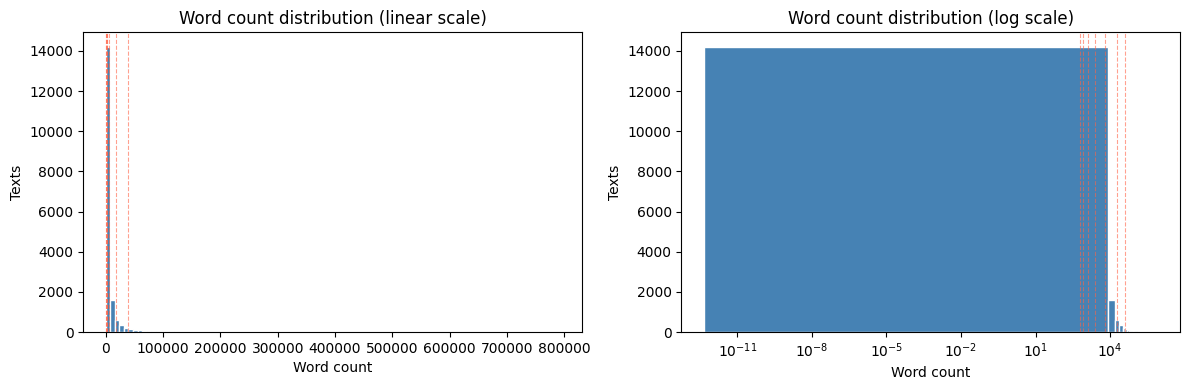

  Percentile     Words
────────────────────────
          5th       619
         10th       786
         25th     1,247
         50th     2,473
         75th     6,195
         90th    18,570
         95th    38,198
────────────────────────
         Min         0
        Mean     9,232
         Max   791,104


In [27]:
words = all_metrics['words'].dropna()
pcts  = [5, 10, 25, 50, 75, 90, 95]
vals  = np.percentile(words, pcts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, xscale in zip(axes, ['linear', 'log']):
    ax.hist(words, bins=100, color='steelblue', edgecolor='white')
    for v in vals:
        ax.axvline(v, color='tomato', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlabel('Word count')
    ax.set_ylabel('Texts')
    ax.set_xscale(xscale)
    ax.set_title(f'Word count distribution ({xscale} scale)')
plt.tight_layout()
plt.savefig(VIS_DIR / 'word_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'Percentile':>12}  {'Words':>8}")
print('─' * 24)
for p, v in zip(pcts, vals):
    print(f"{p:>11}th  {v:>8,.0f}")
print('─' * 24)
print(f"{'Min':>12}  {words.min():>8,.0f}")
print(f"{'Mean':>12}  {words.mean():>8,.0f}")
print(f"{'Max':>12}  {words.max():>8,.0f}")

In [28]:
if not CLEANED_FP.exists():
    MIN_WORDS = 619  # adjust based on distribution above

    n_before    = len(all_metrics)
    all_metrics = all_metrics[all_metrics['words'] >= MIN_WORDS].reset_index(drop=True)
    n_removed   = n_before - len(all_metrics)
    print(f"Minimum length : {MIN_WORDS} words")
    print(f"Removed        : {n_removed} texts  ({100 * n_removed / n_before:.1f}%)")
    print(f"Remaining      : {len(all_metrics)} texts")

    all_metrics.to_csv(CLEANED_FP, index=False)
    print(f"\nSaved cleaned data → {CLEANED_FP}")
else:
    print(f"Using cached cleaned data ({len(all_metrics)} texts) — cache already at {CLEANED_FP}")

Minimum length : 619 words
Removed        : 892 texts  (5.0%)
Remaining      : 16966 texts

Saved cleaned data → /Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper/data/all_metrics_cleaned.csv


In [29]:
FANDOM_ORDER = ['HP', 'LOTR', 'PJ', 'RPF', 'MAG', 'random']

summary = (
    all_metrics
    .assign(published=pd.to_datetime(all_metrics['published']))
    .groupby('fandom_label')
    .agg(
        n=('id', 'size'),
        oldest=('published', 'min'),
        newest=('published', 'max'),
        mean_words=('words', 'mean'),
        sd_words=('words', 'std'),
    )
    .reindex(FANDOM_ORDER)
)
summary['oldest']     = summary['oldest'].dt.date
summary['newest']     = summary['newest'].dt.date
summary['mean_words'] = summary['mean_words'].round(0)
summary['sd_words']   = summary['sd_words'].round(2)

write_table(summary.reset_index(), RESULTS_DIR / 'fandom_summary_cleaned.csv')
summary

,n,oldest,newest,mean_words,sd_words
fandom_label,,,,,
HP,2974,2002-01-19,2023-12-28,13144.0,33090.32
LOTR,2973,2002-02-04,2023-11-17,11853.0,31147.47
PJ,2977,2009-07-22,2023-11-20,8585.0,18722.31
RPF,2609,2000-04-30,2024-03-10,6844.0,21298.32
MAG,2972,2017-01-07,2024-09-03,6688.0,17369.01
random,2461,2022-12-31,2026-01-05,10933.0,36775.17


## Alternative entry point with cleaned and saved data


In [6]:
PROJECT_ROOT = Path('/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper')
TEXT_FP_DETECT = PROJECT_ROOT / 'data' / 'human_texts_2023_2025.csv'
CHR27_FP       = PROJECT_ROOT / 'data' / 'data_subset_chr27.csv'
IN_FP       = PROJECT_ROOT / 'data' / 'AO3metrics_full.csv'
VIS_DIR     = PROJECT_ROOT / 'outputs' / 'visualizations'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results' / 'efa_assumptions'
VIS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

cfg = MetricsConfig()
random.seed(2001)

In [7]:
# Run the imports cell + Paths cell, then this cell instead of everything above it
CLEANED_FP  = PROJECT_ROOT / 'data' / 'all_metrics_cleaned.csv'
all_metrics = pd.read_csv(CLEANED_FP)
print(f"Loaded cached cleaned data → {CLEANED_FP}  ({len(all_metrics):,} rows)")

Loaded cached cleaned data → /Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper/data/all_metrics_cleaned.csv  (16,966 rows)


In [8]:
feat_df, feature_cols, final_category_map, meta_df = prepare_features(
    all_metrics, CATEGORY_OF, set()
)

zero_var = [c for c in feature_cols if feat_df[c].std() == 0]
if zero_var:
    print(f"Dropping {len(zero_var)} zero-variance variable(s): {zero_var}")
    feat_df            = feat_df.drop(columns=zero_var)
    feature_cols       = [c for c in feature_cols if c not in zero_var]
    final_category_map = {k: v for k, v in final_category_map.items() if k in feature_cols}

meta_full      = all_metrics[[c for c in all_metrics.columns if c not in set(feature_cols) and c != 'text']]
scaled_metrics, scaler = scale_metrics(feat_df)
n_obs, n_vars  = scaled_metrics.shape
corr           = np.corrcoef(scaled_metrics, rowvar=False)
print(f'Loaded: {n_obs} observations x {n_vars} variables')

Dropping 1 zero-variance variable(s): ['syllables_per_token_median']
Loaded: 16966 observations x 110 variables


## 1. Sample size

Thresholds: `N > 150` and `N/variable >= 5` (ideally >= 20).

In [9]:
ratio   = n_obs / n_vars
n_pass  = 'PASS' if n_obs > 150 else 'FAIL — need >150'
r_pass  = 'PASS' if ratio >= 5  else 'FAIL — need >=5'
r2_pass = 'PASS' if ratio >= 20 else 'NOTE — ideally >=20'
print(f'N observations  : {n_obs}  ({n_pass})')
print(f'N variables     : {n_vars}')
print(f'N/variable ratio: {ratio:.1f}  ({r_pass} / {r2_pass})')

N observations  : 16966  (PASS)
N variables     : 110
N/variable ratio: 154.2  (PASS / PASS)


## 2. Correlation matrix

- Pairs with `|r| > 0.8`: multicollinearity — remove one from the pair  
- Items where max `|r| < 0.3`: too weakly correlated with everything — consider removing  
- Determinant > 1e-5: required for matrix inversion in EFA

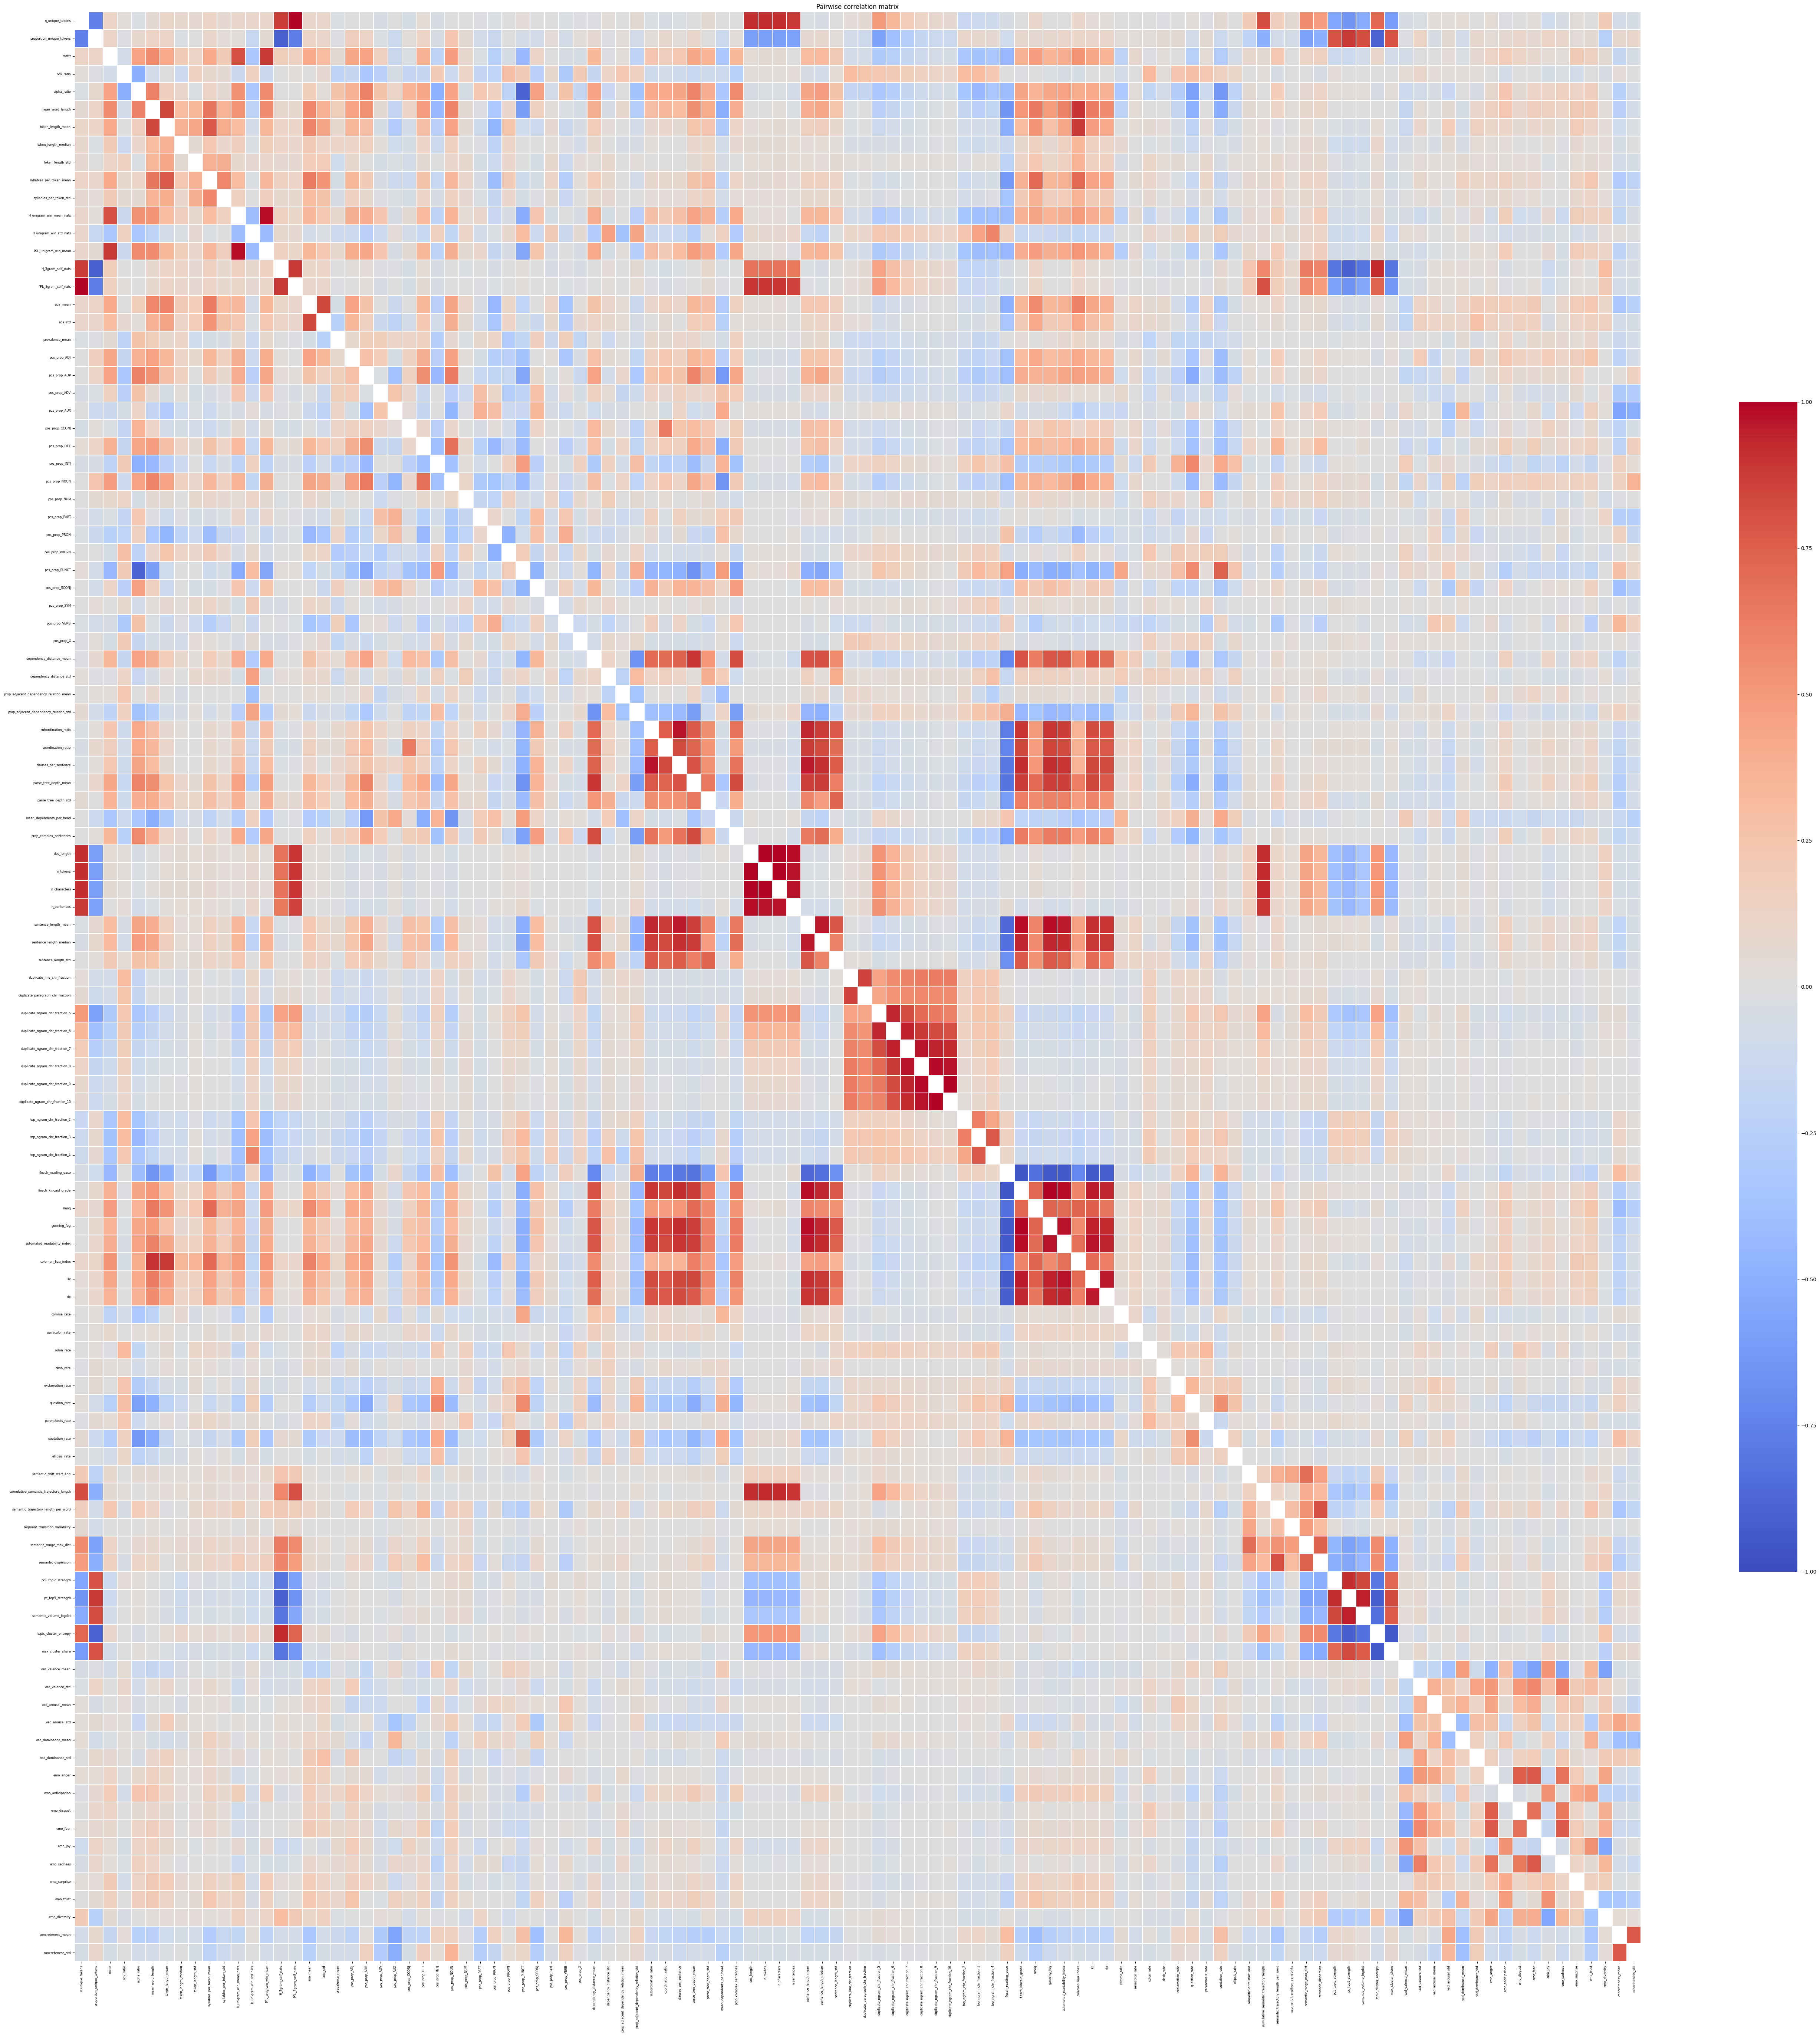

In [10]:
fig_w = max(10, n_vars // 2)
fig_h = max(8,  n_vars // 2)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
mask = np.eye(n_vars, dtype=bool)
sns.heatmap(
    corr, mask=mask, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=feature_cols, yticklabels=feature_cols,
    linewidths=0.3, ax=ax, cbar_kws={'shrink': 0.6}
)
ax.set_title('Pairwise correlation matrix')
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_corr_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
upper    = np.triu(np.abs(corr), k=1)
mc_pairs = [
    (feature_cols[i], feature_cols[j], corr[i, j])
    for i, j in zip(*np.where(upper > 0.8))
]
print(f'Multicollinearity (|r| > 0.8): {len(mc_pairs)} pair(s)')
for a, b, r in mc_pairs:
    print(f'  {a} <-> {b}:  r = {r:.3f}')

off_diag = np.abs(corr - np.eye(n_vars))
max_r    = off_diag.max(axis=1)
weak     = [(feature_cols[i], max_r[i]) for i in range(n_vars) if max_r[i] < 0.3]
print(f'\nWeak correlators (max |r| < 0.3): {len(weak)} variable(s)')
for name, r in weak:
    print(f'  {name}:  max |r| = {r:.3f}')

det      = np.linalg.det(corr)
det_pass = 'PASS' if det > 1e-5 else 'FAIL — near-singular'
print(f'\nDeterminant: {det:.2e}  ({det_pass})')

mc_df   = pd.DataFrame(mc_pairs, columns=['variable_a', 'variable_b', 'r']) if mc_pairs else pd.DataFrame(columns=['variable_a', 'variable_b', 'r'])
weak_df = pd.DataFrame(weak, columns=['variable', 'max_r']) if weak else pd.DataFrame(columns=['variable', 'max_r'])
write_table(mc_df,   RESULTS_DIR / 'corr_multicollinearity.csv')
write_table(weak_df, RESULTS_DIR / 'corr_weak_variables.csv')

Multicollinearity (|r| > 0.8): 121 pair(s)
  n_unique_tokens <-> H_3gram_self_nats:  r = 0.869
  n_unique_tokens <-> PPL_3gram_self_nats:  r = 0.995
  n_unique_tokens <-> doc_length:  r = 0.916
  n_unique_tokens <-> n_tokens:  r = 0.917
  n_unique_tokens <-> n_characters:  r = 0.920
  n_unique_tokens <-> n_sentences:  r = 0.888
  n_unique_tokens <-> cumulative_semantic_trajectory_length:  r = 0.814
  proportion_unique_tokens <-> H_3gram_self_nats:  r = -0.903
  proportion_unique_tokens <-> pc_top5_strength:  r = 0.884
  proportion_unique_tokens <-> semantic_volume_logdet:  r = 0.814
  proportion_unique_tokens <-> topic_cluster_entropy:  r = -0.898
  mattr <-> H_unigram_win_mean_nats:  r = 0.805
  mattr <-> PPL_unigram_win_mean:  r = 0.889
  alpha_ratio <-> pos_prop_PUNCT:  r = -0.886
  mean_word_length <-> token_length_mean:  r = 0.841
  mean_word_length <-> coleman_liau_index:  r = 0.902
  token_length_mean <-> coleman_liau_index:  r = 0.889
  H_unigram_win_mean_nats <-> PPL_unigram_w

In [12]:
rows = []
for i, (a, b, r_ab) in enumerate(mc_pairs, 1):
    others  = [c for c in feature_cols if c not in (a, b)]
    idx_a   = feature_cols.index(a)
    idx_b   = feature_cols.index(b)
    idx_o   = [feature_cols.index(c) for c in others]
    reach_a = np.nanmean(np.abs(corr[idx_a][idx_o]))
    reach_b = np.nanmean(np.abs(corr[idx_b][idx_o]))
    keep    = a if reach_a >= reach_b else b
    drop    = b if keep == a else a

    print(f"Pair {i}/{len(mc_pairs)}:  {a}  <->  {b}  (r = {r_ab:.3f})")
    print(f"  {a:<50}  reach = {reach_a:.3f}")
    print(f"  {b:<50}  reach = {reach_b:.3f}")
    print(f"  --> KEEP: {keep}")
    print(f"      DROP: {drop}")
    print()

    rows.append({
        'variable_a': a, 'variable_b': b, 'r': round(r_ab, 3),
        'reach_a': round(reach_a, 3), 'reach_b': round(reach_b, 3),
        'recommended_keep': keep, 'recommended_drop': drop,
    })

mc_recommendation_df = pd.DataFrame(rows)
write_table(mc_recommendation_df, RESULTS_DIR / 'corr_multicollinearity_recommendations.csv')
print(f"Saved recommendations for {len(rows)} pair(s).")

Pair 1/121:  n_unique_tokens  <->  H_3gram_self_nats  (r = 0.869)
  n_unique_tokens                                     reach = 0.144
  H_3gram_self_nats                                   reach = 0.154
  --> KEEP: H_3gram_self_nats
      DROP: n_unique_tokens

Pair 2/121:  n_unique_tokens  <->  PPL_3gram_self_nats  (r = 0.995)
  n_unique_tokens                                     reach = 0.143
  PPL_3gram_self_nats                                 reach = 0.145
  --> KEEP: PPL_3gram_self_nats
      DROP: n_unique_tokens

Pair 3/121:  n_unique_tokens  <->  doc_length  (r = 0.916)
  n_unique_tokens                                     reach = 0.144
  doc_length                                          reach = 0.121
  --> KEEP: n_unique_tokens
      DROP: doc_length

Pair 4/121:  n_unique_tokens  <->  n_tokens  (r = 0.917)
  n_unique_tokens                                     reach = 0.144
  n_tokens                                            reach = 0.120
  --> KEEP: n_unique_tokens
      

In [13]:
# Build adjacency list from collinear pairs
neighbours = defaultdict(set)
for a, b, _ in mc_pairs:
    neighbours[a].add(b)
    neighbours[b].add(a)

remaining = set(feature_cols)
to_drop   = set()

while True:
    # Find all edges that still exist among remaining variables
    active_edges = [
        (a, b) for a, b, _ in mc_pairs
        if a in remaining and b in remaining
    ]
    if not active_edges:
        break

    # Count collinear neighbours still in play for each variable
    degree = defaultdict(int)
    for a, b in active_edges:
        degree[a] += 1
        degree[b] += 1

    # Drop the variable with the most collinear neighbours anfd break ties by choosing the one with the lower reach
    max_deg  = max(degree.values())
    tied     = [v for v, d in degree.items() if d == max_deg]
    idx_map  = {c: i for i, c in enumerate(feature_cols)}
    drop_var = min(tied, key=lambda v: np.nanmean(np.abs(corr[idx_map[v]][[idx_map[c] for c in feature_cols if c != v]])))

    to_drop.add(drop_var)
    remaining.discard(drop_var)

print(f"Variables to drop  : {len(to_drop)}")
print(f"Variables to keep  : {len(remaining)}")
print(f"\nDROP ({len(to_drop)}):")
for v in sorted(to_drop):
    print(f"  {v}")

drop_df = pd.DataFrame(sorted(to_drop), columns=['variable'])
write_table(drop_df, RESULTS_DIR / 'collinearity_drop_list.csv')

Variables to drop  : 32
Variables to keep  : 78

DROP (32):
  H_3gram_self_nats
  H_unigram_win_mean_nats
  aoa_std
  automated_readability_index
  clauses_per_sentence
  cumulative_semantic_trajectory_length
  dependency_distance_mean
  doc_length
  duplicate_ngram_chr_fraction_10
  duplicate_ngram_chr_fraction_6
  duplicate_ngram_chr_fraction_7
  duplicate_ngram_chr_fraction_9
  duplicate_paragraph_chr_fraction
  flesch_kincaid_grade
  flesch_reading_ease
  gunning_fog
  lix
  mattr
  mean_word_length
  n_characters
  n_sentences
  n_tokens
  n_unique_tokens
  pc_top5_strength
  pos_prop_PUNCT
  prop_complex_sentences
  semantic_trajectory_length_per_word
  semantic_volume_logdet
  sentence_length_mean
  sentence_length_median
  token_length_mean
  topic_cluster_entropy


In [14]:
idx_map_all  = {c: i for i, c in enumerate(feature_cols)}
reach_all    = {
    v: np.nanmean(np.abs(corr[idx_map_all[v]][[idx_map_all[c] for c in feature_cols if c != v]]))
    for v in feature_cols
}
orig_degree = defaultdict(int)
for a, b, _ in mc_pairs:
    orig_degree[a] += 1
    orig_degree[b] += 1

summary_df = pd.DataFrame([{
    'variable':        v,
    'category':        CATEGORY_OF.get(v, 'unknown'),
    'status':          'DROP' if v in to_drop else 'KEEP',
    'reach':           round(reach_all[v], 3),
    'collinear_pairs': orig_degree.get(v, 0),
} for v in feature_cols]).sort_values(
    ['category', 'status', 'reach'], ascending=[True, True, False]
)

for cat, grp in summary_df.groupby('category'):
    n_keep = (grp['status'] == 'KEEP').sum()
    n_drop = (grp['status'] == 'DROP').sum()
    print(f"\n{'='*65}")
    print(f"  {cat}  —  keep {n_keep}  /  drop {n_drop}")
    print(f"{'='*65}")
    print(grp[['status', 'variable', 'reach', 'collinear_pairs']].to_string(index=False))

write_table(summary_df, RESULTS_DIR / 'collinearity_summary_by_category.csv')


  Affect Dimensions  —  keep 6  /  drop 0
status           variable  reach  collinear_pairs
  KEEP   vad_valence_mean  0.097                0
  KEEP    vad_arousal_std  0.097                0
  KEEP    vad_valence_std  0.089                0
  KEEP vad_dominance_mean  0.079                0
  KEEP   vad_arousal_mean  0.069                0
  KEEP  vad_dominance_std  0.064                0

  Clustering & Diversity  —  keep 1  /  drop 1
status              variable  reach  collinear_pairs
  DROP topic_cluster_entropy  0.142                5
  KEEP     max_cluster_share  0.126                3

  Coherence & Trajectory  —  keep 3  /  drop 2
status                              variable  reach  collinear_pairs
  DROP   semantic_trajectory_length_per_word  0.127                1
  DROP cumulative_semantic_trajectory_length  0.114                6
  KEEP               semantic_range_max_dist  0.140                0
  KEEP              semantic_drift_start_end  0.073                0
  KEEP 

In [15]:
n_tokens_vals = all_metrics['n_tokens'].values
length_corr = pd.Series(
    {col: np.corrcoef(feat_df[col].values, n_tokens_vals)[0, 1] for col in feature_cols},
    name='r_with_n_tokens'
).sort_values(key=abs, ascending=False)

print(length_corr.head(10).to_string())

n_tokens                                 1.000000
n_characters                             0.999363
doc_length                               0.999307
n_sentences                              0.972097
cumulative_semantic_trajectory_length    0.924432
n_unique_tokens                          0.917231
PPL_3gram_self_nats                      0.895304
H_3gram_self_nats                        0.677595
proportion_unique_tokens                -0.599897
duplicate_ngram_chr_fraction_5           0.516020


### Manual overrides to drop list 

In [16]:
# weak correlators (max |r| < 0.3) — no real signal to contribute
force_drop = {'pos_prop_X', 'pos_prop_NUM', 'pos_prop_SYM', 'PPL_3gram_self_nats'}

# algorithm auto-DROP'd them, but reach/pairs alone isn't the full story
force_rescue = {'semantic_volume_logdet', 'prop_complex_sentences'}


to_drop = (to_drop | force_drop) - force_rescue

print("Manual overrides applied:")
print(f"  Added to drop    : {sorted(force_drop)}")
print(f"  Rescued from drop: {sorted(force_rescue)}")
print(f"\nFinal drop count : {len(to_drop)}")
print(f"Final keep count : {len(feature_cols) - len(to_drop)}")

Manual overrides applied:
  Added to drop    : ['PPL_3gram_self_nats', 'pos_prop_NUM', 'pos_prop_SYM', 'pos_prop_X']
  Rescued from drop: ['prop_complex_sentences', 'semantic_volume_logdet']

Final drop count : 34
Final keep count : 76


In [17]:
# Apply collinearity drop list — create cleaned variable set for KMO and beyond
keep_cols      = [c for c in feature_cols if c not in to_drop]
keep_idx       = [feature_cols.index(c) for c in keep_cols]
scaled_clean   = scaled_metrics[:, keep_idx]
category_clean = {c: final_category_map[c] for c in keep_cols}
corr_clean     = np.corrcoef(scaled_clean, rowvar=False)

det_clean = np.linalg.det(corr_clean)
print(f"Variables after collinearity resolution : {len(keep_cols)}")
print(f"Determinant (cleaned matrix)            : {det_clean:.2e}")

Variables after collinearity resolution : 76
Determinant (cleaned matrix)            : 2.66e-28


## 3. Normality

EFA is robust to mild non-normality. Flag variables with `|skew| > 2` or `|kurt| > 7`; consider log or sqrt transformation if needed.

In [18]:
norm_df = pd.DataFrame({
    'skewness': stats.skew(scaled_clean),
    'kurtosis': stats.kurtosis(scaled_clean),
}, index=keep_cols).sort_values('skewness', key=abs, ascending=False)

flagged = norm_df[(norm_df['skewness'].abs() > 2) | (norm_df['kurtosis'].abs() > 7)]
print(f'Variables flagged (|skew|>2 or |kurt|>7): {len(flagged)}')
print(norm_df.to_string())

Variables flagged (|skew|>2 or |kurt|>7): 41
                                         skewness     kurtosis
token_length_std                        38.701081  2410.469878
rix                                     30.262963  2223.356840
syllables_per_token_std                 20.840209   672.240756
duplicate_line_chr_fraction             20.721117   669.586368
emo_disgust                             20.353644  1293.830984
duplicate_ngram_chr_fraction_8          17.941400   523.989331
emo_anger                               15.987951   958.125464
colon_rate                              15.902196   356.581088
subordination_ratio                     14.666999   550.512436
coordination_ratio                      13.013854   529.588295
parenthesis_rate                        12.619219   267.069242
top_ngram_chr_fraction_4                10.852766   226.063139
dependency_distance_std                 10.638238   315.226604
H_unigram_win_std_nats                  10.047203   186.929153
sentence_l

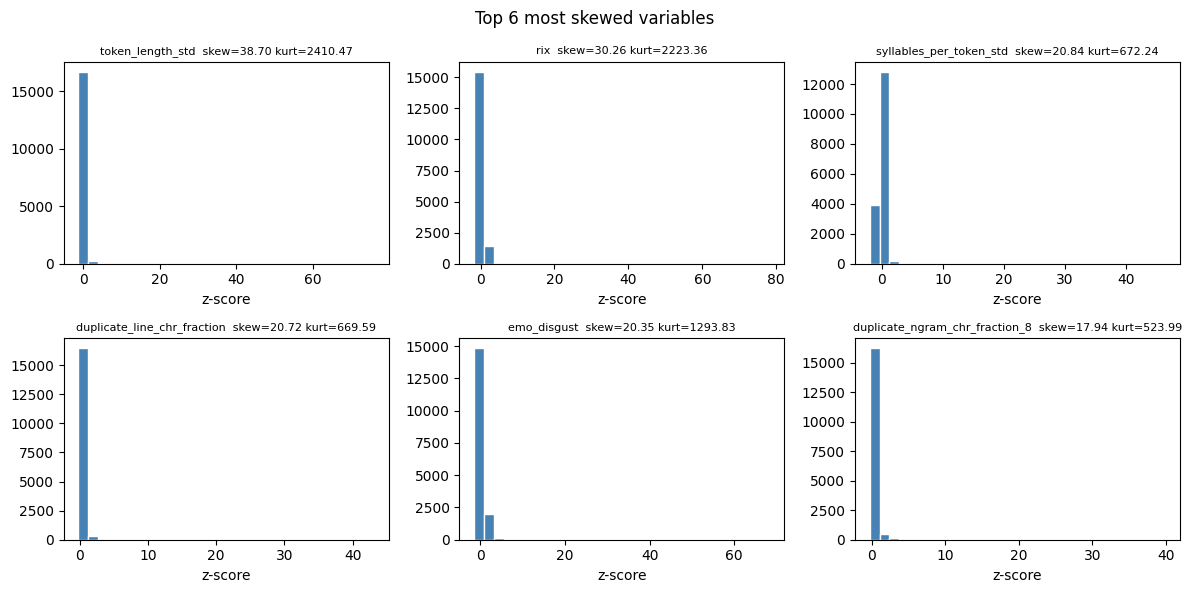

In [19]:
top_vars = norm_df.head(min(6, len(norm_df))).index.tolist()
idx_map  = {c: i for i, c in enumerate(feature_cols)}
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
for ax, col in zip(axes, top_vars):
    ax.hist(scaled_metrics[:, idx_map[col]], bins=30, color='steelblue', edgecolor='white')
    skew_val = norm_df.loc[col, 'skewness']
    kurt_val = norm_df.loc[col, 'kurtosis']
    ax.set_title(f'{col}  skew={skew_val:.2f} kurt={kurt_val:.2f}', fontsize=8)
    ax.set_xlabel('z-score')
for ax in axes[len(top_vars):]:
    ax.set_visible(False)
plt.suptitle('Top 6 most skewed variables')
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_norm_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

### Yeo-Johnson transform + drop sparse POS tags

Drop near-zero sparse POS categories (`pos_prop_X`, `pos_prop_NUM`, `pos_prop_INTJ`) these are noise in a prose corpus and do not transform to normality because >90 % of values are zero
Yeo-Johnson all remaining flagged variables (handles zeros, negatives, and both skew directions) Applied to raw `feat_df` before z-scoring so the correlation matrix is built on transformed values

This cell overwrites `keep_cols`, `scaled_metrics`, `scaled_clean`, and `corr_clean` so all downstream cells use the transformed data.

In [20]:
text_df = texts.set_index('id')

META_COLS = ['id', 'title', 'author', 'fandom']

def show_extreme_texts(col, n=50, prefix_len=1000, largest=True):
    """Show text previews for observations with the most extreme raw values for `col`."""
    raw = all_metrics[col] if col in all_metrics.columns else feat_df[col]
    top = raw.nlargest(n) if largest else raw.nsmallest(n)
    direction = 'largest' if largest else 'smallest'
    print(f"Top {n} {direction} raw values for '{col}'\n")
    for rank, (idx, val) in enumerate(top.items(), 1):
        row      = all_metrics.loc[idx]
        work_id  = row['id']
        text     = text_df.loc[work_id, 'text'] if work_id in text_df.index else '(not found)'
        print(f"{'─'*60}")
        print(f"Rank {rank}  |  {col} = {val:.4f}")
        for c in META_COLS:
            if c in all_metrics.columns:
                print(f"  {c}: {row[c]}")
        print()
        print(text[:prefix_len])
        print()

show_extreme_texts('token_length_std', n=100)

NameError: name 'texts' is not defined

In [21]:
# Near-zero sparse POS tags (>90% zero) cannot be normalized — drop rather than transform
drop_nonnormal = {'pos_prop_X', 'pos_prop_SYM', 'token_length_median'}

flagged_names = set(flagged.index)
to_transform  = [c for c in flagged_names
                 if c not in drop_nonnormal and c in feat_df.columns]

print(f"Dropping (sparse, untransformable) : {sorted(drop_nonnormal & set(keep_cols))}")
print(f"Yeo-Johnson transform applied to   : {len(to_transform)} variable(s)")

# Transform raw feat_df, then re-scale
feat_yj = feat_df.copy()
pt      = PowerTransformer(method='yeo-johnson', standardize=False)
feat_yj[to_transform] = pt.fit_transform(feat_df[to_transform])

# Update shared state (overwrites variables used by downstream cells)
to_drop        = to_drop | drop_nonnormal
keep_cols      = [c for c in feature_cols if c not in to_drop]
keep_idx       = [feature_cols.index(c) for c in keep_cols]
category_clean = {c: final_category_map[c] for c in keep_cols}

scaled_metrics, scaler = scale_metrics(feat_yj)
scaled_clean           = scaled_metrics[:, keep_idx]
corr_clean             = np.corrcoef(scaled_clean, rowvar=False)

print(f"\nFinal variable count: {len(keep_cols)}")

# Re-check normality
norm_df2 = pd.DataFrame({
    'skewness': stats.skew(scaled_clean),
    'kurtosis': stats.kurtosis(scaled_clean),
}, index=keep_cols).sort_values('skewness', key=abs, ascending=False)

flagged2 = norm_df2[(norm_df2['skewness'].abs() > 2) | (norm_df2['kurtosis'].abs() > 7)]
print(f"\nVariables still flagged after transform (|skew|>2 or |kurt|>7): {len(flagged2)}")
print(flagged2.to_string())

write_table(norm_df2, RESULTS_DIR / 'normality_after_transform.csv')

Dropping (sparse, untransformable) : ['token_length_median']
Yeo-Johnson transform applied to   : 40 variable(s)

Final variable count: 75

Variables still flagged after transform (|skew|>2 or |kurt|>7): 4
                                        skewness   kurtosis
prop_adjacent_dependency_relation_mean  1.450828  76.818232
coleman_liau_index                      0.752302  32.305536
dependency_distance_std                -0.398705  12.142695
sentence_length_std                    -0.287245  11.173678


## 4. Outliers

Per-variable z-scores: flag observations where any variable has `|z| > 3.5`.  
Since `scaled_metrics` is already standardised, each column is directly on the z-score scale.

In [22]:
z_max        = np.abs(scaled_clean).max(axis=1)
outlier_mask = z_max > 3.5
n_out        = int(outlier_mask.sum())
print(f'Observations with any |z| > 3.5: {n_out} ({100 * n_out / n_obs:.1f}%)')

if n_out > 0:
    out_idx   = np.where(outlier_mask)[0]
    worst_var = [keep_cols[np.abs(scaled_clean[i]).argmax()] for i in out_idx]
    out_df    = meta_full.iloc[out_idx].copy().reset_index(drop=True)
    out_df['max_z']          = z_max[outlier_mask]
    out_df['worst_variable'] = worst_var
    print(out_df.sort_values('max_z', ascending=False).to_string())

Observations with any |z| > 3.5: 1495 (8.8%)
            id                                                                                                                                                                                                                                                      title                                                                                   author                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [23]:
WINSOR_THRESH  = 3.5
n_clipped      = int((np.abs(scaled_clean) > WINSOR_THRESH).sum())
max_z_before   = float(np.abs(scaled_clean).max())
scaled_clean   = np.clip(scaled_clean, -WINSOR_THRESH, WINSOR_THRESH)
corr_clean     = np.corrcoef(scaled_clean, rowvar=False)

print(f"Winsorisation")
print(f"Threshold          : ±{WINSOR_THRESH} SD")
print(f"Values clipped     : {n_clipped}  (across {n_out} flagged observations)")
print(f"Max |z| before     : {max_z_before:.2f}")
print(f"Max |z| after      : {np.abs(scaled_clean).max():.2f}")
print(f"scaled_clean and corr_clean updated — proceed to KMO")

Winsorisation
Threshold          : ±3.5 SD
Values clipped     : 3091  (across 1495 flagged observations)
Max |z| before     : 32.89
Max |z| after      : 3.50
scaled_clean and corr_clean updated — proceed to KMO


In [24]:
det_clean = np.linalg.det(corr_clean)
print(f"Variables after all assumptions besides KMO and Bartlett's tested : {len(keep_cols)}")
print(f"Determinant (cleaned matrix)            : {det_clean:.2e}")

Variables after all assumptions besides KMO and Bartlett's tested : 75
Determinant (cleaned matrix)            : 7.42e-31


## 5. KMO & Bartlett's test

- Overall KMO >= 0.60 (adequate) / >= 0.80 (good)  
- Bartlett p < 0.05: correlation matrix is not an identity matrix  
- Per-variable MSA >= 0.50: items below this are candidates for removal

In [25]:
kmo_all, kmo_model = calculate_kmo(scaled_clean)
chi2, p_val        = calculate_bartlett_sphericity(scaled_clean)
bart_df             = len(keep_cols) * (len(keep_cols) - 1) // 2

kmo_pass  = 'PASS' if kmo_model >= 0.6 else 'FAIL — need >=0.60'
bart_pass = 'PASS' if p_val < 0.05     else 'FAIL — need p<0.05'
print(f'Overall KMO     : {kmo_model:.3f}  ({kmo_pass})')
print(f"Bartlett's test  : chi2({bart_df}) = {chi2:.2f}, p = {p_val:.3e}  ({bart_pass})")

msa_series = pd.Series(kmo_all, index=keep_cols).sort_values()
low_msa    = msa_series[msa_series < 0.5]
print(f'\nPer-variable MSA < 0.50: {len(low_msa)} variable(s)')
if not low_msa.empty:
    print(low_msa.to_string())

Overall KMO     : 0.786  (PASS)
Bartlett's test  : chi2(2775) = 1175164.62, p = 0.000e+00  (PASS)

Per-variable MSA < 0.50: 6 variable(s)
pos_prop_PROPN    0.234352
pos_prop_ADV      0.329466
pos_prop_PRON     0.393200
pos_prop_VERB     0.418716
pos_prop_PART     0.454144
pos_prop_AUX      0.470444


/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


### Iterative MSA-based pruning

Per-variable MSA is relative to whichever other variables are still in the matrix  dropping the worst one can pull the others back above 0.50, esp—ecially for compositional families like POS proportions. Drop the single worst-MSA variable, recompute KMO/MSA on what's left, and repeat until none remain flagged.

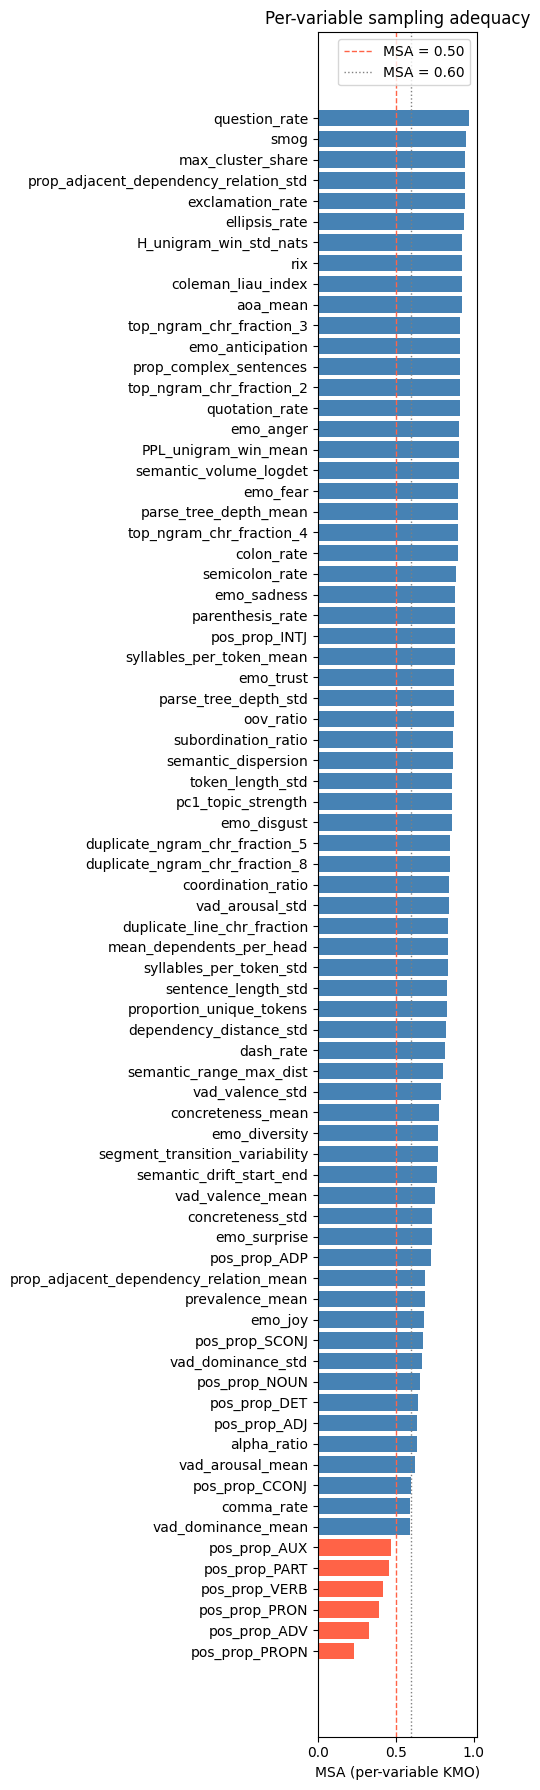

In [26]:
fig, ax = plt.subplots(figsize=(5, max(6, len(keep_cols) // 4)))
colors  = ['tomato' if v < 0.5 else 'steelblue' for v in msa_series.values]
ax.barh(msa_series.index, msa_series.values, color=colors)
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1, label='MSA = 0.50')
ax.axvline(0.6, color='gray',   linestyle=':',  linewidth=1, label='MSA = 0.60')
ax.set_xlabel('MSA (per-variable KMO)')
ax.set_title('Per-variable sampling adequacy')
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / 'noalpharatio_efa_msa.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
msa_drop_log = []
while True:
    kmo_all, kmo_model = calculate_kmo(scaled_clean)
    msa_series = pd.Series(kmo_all, index=keep_cols).sort_values()
    low_msa    = msa_series[msa_series < 0.5]
    if low_msa.empty:
        break

    worst_var = low_msa.index[0]
    worst_msa = low_msa.iloc[0]
    print(f"Dropping {worst_var:<25}  (MSA={worst_msa:.3f}, overall KMO={kmo_model:.3f})")
    msa_drop_log.append({'variable': worst_var, 'msa': round(worst_msa, 3), 'kmo_before_drop': round(kmo_model, 3)})

    drop_idx     = keep_cols.index(worst_var)
    keep_cols    = [c for c in keep_cols if c != worst_var]
    scaled_clean = np.delete(scaled_clean, drop_idx, axis=1)
    to_drop.add(worst_var)

keep_idx       = [feature_cols.index(c) for c in keep_cols]
category_clean = {c: final_category_map[c] for c in keep_cols}
corr_clean     = np.corrcoef(scaled_clean, rowvar=False)

print(f"\nVariables dropped for low MSA : {len(msa_drop_log)}")
print(f"Final variable count          : {len(keep_cols)}")
print(f"Final overall KMO             : {kmo_model:.3f}")

msa_drop_df = pd.DataFrame(msa_drop_log)
write_table(msa_drop_df, RESULTS_DIR / 'msa_iterative_drop_log.csv')

Dropping pos_prop_PROPN             (MSA=0.234, overall KMO=0.786)

Variables dropped for low MSA : 1
Final variable count          : 74
Final overall KMO             : 0.849


/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


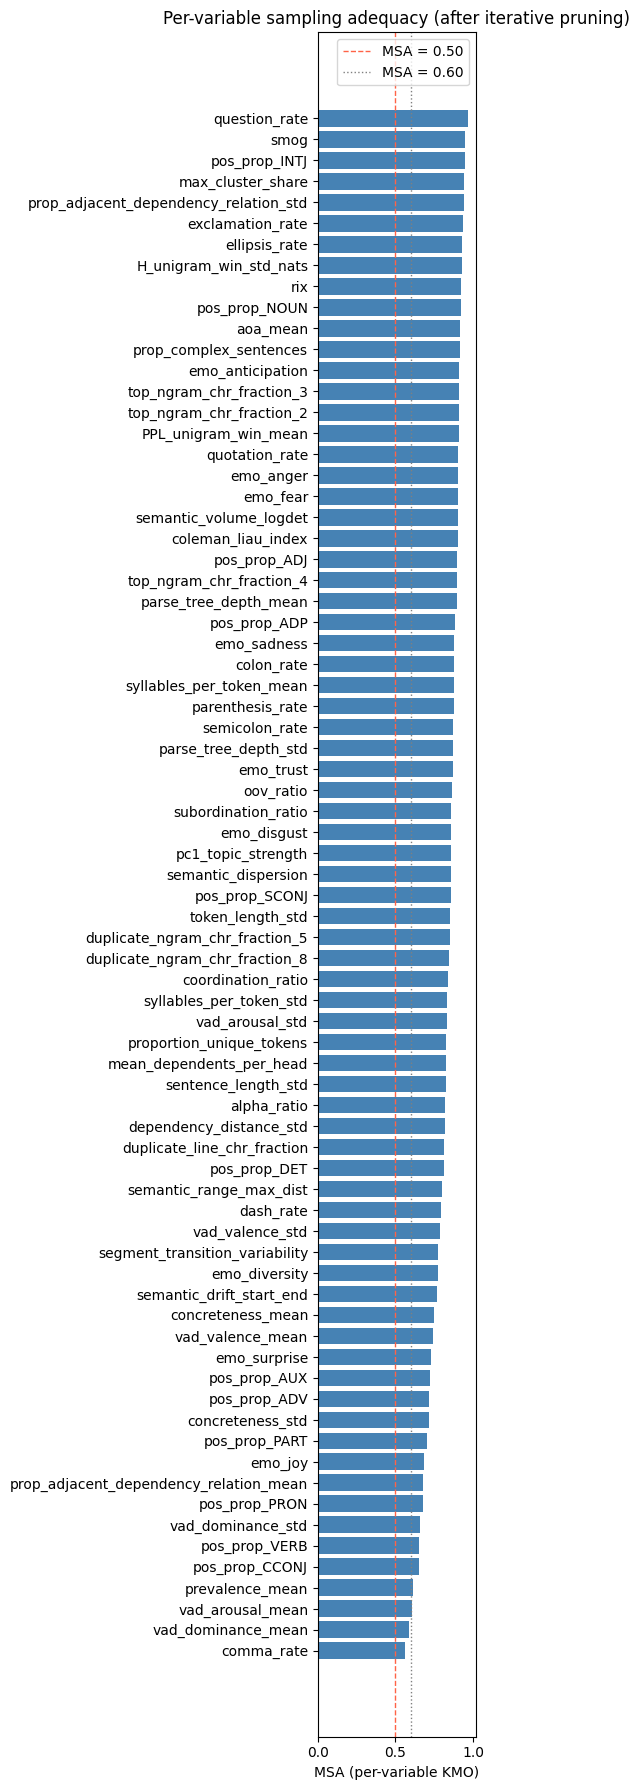

In [28]:
fig, ax = plt.subplots(figsize=(5, max(6, len(keep_cols) // 4)))
colors  = ['tomato' if v < 0.5 else 'steelblue' for v in msa_series.values]
ax.barh(msa_series.index, msa_series.values, color=colors)
ax.axvline(0.5, color='tomato', linestyle='--', linewidth=1, label='MSA = 0.50')
ax.axvline(0.6, color='gray',   linestyle=':',  linewidth=1, label='MSA = 0.60')
ax.set_xlabel('MSA (per-variable KMO)')
ax.set_title('Per-variable sampling adequacy (after iterative pruning)')
ax.legend()
plt.tight_layout()
plt.savefig(VIS_DIR / 'efa_msa_after_pruning.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
kmo_all_final, kmo_model_final = calculate_kmo(scaled_clean)
chi2_final, p_val_final        = calculate_bartlett_sphericity(scaled_clean)
bart_df_final                  = len(keep_cols) * (len(keep_cols) - 1) // 2
det_clean                      = np.linalg.det(corr_clean)

print(f"Variables after all assumptions tested : {len(keep_cols)}")
print(f"Determinant (cleaned matrix)            : {det_clean:.2e}")
print(f"Final overall KMO                       : {kmo_model_final:.3f}")
print(f"Final Bartlett's test                   : chi2({bart_df_final}) = {chi2_final:.2f}, p = {p_val_final:.3e}")

Variables after all assumptions tested : 74
Determinant (cleaned matrix)            : 6.54e-30
Final overall KMO                       : 0.849
Final Bartlett's test                   : chi2(2701) = 1138322.95, p = 0.000e+00


/Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [30]:
# Alternative entry point
# Run the imports cell + paths cell, then this cell instead of sections 1–5.
STATE_PATH = PROJECT_ROOT / 'data' / 'efa_state.joblib'

joblib.dump({
    'scaled_metrics':     scaled_metrics,
    'scaled_clean':       scaled_clean,
    'corr_clean':         corr_clean,
    'feature_cols':       feature_cols,
    'keep_cols':          keep_cols,
    'final_category_map': final_category_map,
    'category_clean':     category_clean,
    'n_obs':              n_obs,
    'n_vars':             n_vars,
    'meta_full':          meta_full,
}, STATE_PATH)

print(f"Saved → {STATE_PATH}")
print(f"  scaled_metrics : {scaled_metrics.shape}  (all vars, YJ-transformed, z-scored)")
print(f"  scaled_clean   : {scaled_clean.shape}  ({len(keep_cols)} vars, winsorized)")
print(f"  meta_full      : {meta_full.shape}  (same row order as scaled_metrics/scaled_clean)")

Saved → /Users/au728638/Library/CloudStorage/OneDrive-Aarhusuniversitet/Desktop/3. PhD Project/3. Code/chr_stability_paper/data/efa_state.joblib
  scaled_metrics : (16966, 110)  (all vars, YJ-transformed, z-scored)
  scaled_clean   : (16966, 74)  (74 vars, winsorized)
  meta_full      : (16966, 25)  (same row order as scaled_metrics/scaled_clean)
